In [1]:
%pip install pandas


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy as sp
from IPython.display import display, clear_output
import matplotlib.animation as animation
from matplotlib.colors import Normalize
import time
import pandas as pd
import random


In [3]:
def get_truncated_normal(mean=0.5, sd=0.1, low=0, high=1, rng=None):
    """Return a single sample from a truncated normal distribution.

    Parameters
    ----------
    mean : float
        Mean of the underlying normal.
    sd : float
        Standard deviation of the underlying normal.
    low : float
        Lower bound of the truncation.
    high : float
        Upper bound of the truncation.
    rng : np.random.Generator, optional
        Random number generator.  If None a new default_rng() is created.

    Returns
    -------
    float
        One sample from TruncNorm(mean, sd, [low, high]).
    """
    a = (low - mean) / sd
    b = (high - mean) / sd
    return sp.stats.truncnorm(a, b, loc=mean, scale=sd).rvs(random_state=rng)


def gini(x):
    """Standard Gini coefficient for a 1-D array of non-negative wealth values.

    Parameters
    ----------
    x : array-like
        Non-negative wealth values.

    Returns
    -------
    float
        Gini coefficient in [0, 1].
    """
    x = np.asarray(x, dtype=float)
    if x.size == 0 or np.all(x == 0):
        return 0.0
    x = np.sort(x)
    n = x.size
    cum = np.cumsum(x)
    return (2 * np.sum((np.arange(1, n + 1)) * x) - (n + 1) * cum[-1]) / (n * cum[-1])


def initialize_bundle(n_goods, mode="uniform", rng=None, low=5.0, high=25.0):
    """Return a length-n_goods ndarray of initial holdings.

    Parameters
    ----------
    n_goods : int
        Number of goods.
    mode : str
        One of "single_random", "uniform", or "empty".
        - "single_random": one good gets a uniform[low, high] amount, others 0.
        - "uniform":       every good gets uniform[low, high] independently.
        - "empty":         all zeros.
    rng : np.random.Generator, optional
        Random number generator.
    low : float
        Lower bound for uniform draws.
    high : float
        Upper bound for uniform draws.

    Returns
    -------
    np.ndarray
        Shape (n_goods,).
    """
    if rng is None:
        rng = np.random.default_rng()
    if mode == "single_random":
        bundle = np.zeros(n_goods)
        g = rng.integers(n_goods)
        bundle[g] = rng.uniform(low, high)
        return bundle
    elif mode == "uniform":
        return rng.uniform(low, high, size=n_goods)
    elif mode == "empty":
        return np.zeros(n_goods)
    raise ValueError(f"Unknown mode: {mode}")


In [4]:
from matplotlib.pylab import array


class Agent:
    """An agent in the Sugarscape model.

    Parameters
    ----------
    id : int
        Unique agent identifier.
    preferences : np.ndarray
        Shape (n_goods,) of Cobb-Douglas preference weights (alphas).
    bundle : np.ndarray
        Shape (n_goods,) initial holdings of each good.
    vision : int
        Chebyshev radius the agent can see and move within.
    position : tuple[int, int]
        (row, col) grid position.
    metabolic_rate : np.ndarray
        Shape (n_goods,) per-good consumption rate per step.
    """

    

    def __init__(self, id, preferences, bundle, vision, position, metabolic_rate):
        self.id = id
        self.preferences = np.asarray(preferences, dtype=float)
        self.bundle = np.asarray(bundle, dtype=float)
        self.vision = vision
        self.position = position
        self.metabolic_rate = np.asarray(metabolic_rate, dtype=float)
        self.trade_history = {'Price': [], 'Quantity Bought': [], 'Quantity Sold': [], 'Good Given': [], 'Good Received': [], 'Partner ID': []}

    # ------------------------------------------------------------------
    # Welfare / preferences
    # ------------------------------------------------------------------

    def utility_function(self, bundle):
        """Cobb-Douglas welfare: U = prod(bundle[g] ** (alpha[g] / sum(alpha))).

        Parameters
        ----------
        bundle : np.ndarray
            Shape (n_goods,) resource quantities.

        Returns
        -------
        float
            Welfare value (>= 0).  Zero if any bundle entry is <= 0.
        """
        alpha = self.preferences / self.preferences.sum()
        return float(np.prod(np.power(bundle, alpha)))

    # ------------------------------------------------------------------
    # Trade helpers (not wired up yet)
    # ------------------------------------------------------------------

    def _calc_mrs(self, good_i, good_j):
        """Marginal rate of substitution: units of good j per unit of good i.

        Parameters
        ----------
        good_i : int
            Index of the good being given up.
        good_j : int
            Index of the good being received.

        Returns
        -------
        float
            MRS value.
        """
        weight_good_i = self.preferences[good_i]
        weight_good_j = self.preferences[good_j]
        quantity_good_i = self.bundle[good_i]
        quantity_good_j = self.bundle[good_j]

        if quantity_good_i <= 0:
            return np.inf  #
         
        if quantity_good_j <= 0:
            return 0.0  

        return (quantity_good_j / weight_good_j) / (quantity_good_i / weight_good_i)
    

    #
    # Trade
    #


    def trade(self, other_agent, good_i, good_j):
        """Attempt to trade with another agent.

        Parameters
        ----------
        other_agent : Agent
            The agent to trade with.

        
        """
        while True:
            mrs_self = self._calc_mrs(good_i, good_j)
            mrs_other = other_agent._calc_mrs(good_i, good_j)
            #Higher mrs means more of good i per unit of good j, so self wants to give up good i and get good j, while other wants the opposite.  If they're equal, no mutually beneficial trade is possible.

            if abs(mrs_self - mrs_other) < 1e-6:
                break

            price = np.sqrt(mrs_self * mrs_other)

            q_buy, q_sell = 0, 0

            if price >= 1:
                q_buy = 1
                q_sell = price
            else:
                q_buy = 1 / price
                q_sell = 1
            



            if mrs_self > mrs_other:
                buyer = self
                seller = other_agent
            else:
                buyer = other_agent
                seller = self

            if seller.bundle[good_i] < q_buy or buyer.bundle[good_j] < q_sell:
                return
            
            # Compute prospective bundles using indexed mutation (was using a 2-element
            # list which only works for n_goods=2; this generalises and makes the seller
            # lose good_i / gain good_j and the buyer the reverse).
            new_seller_bundle = seller.bundle.copy()
            new_seller_bundle[good_i] -= q_buy
            new_seller_bundle[good_j] += q_sell
            new_buyer_bundle  = buyer.bundle.copy()
            new_buyer_bundle[good_i]  += q_buy
            new_buyer_bundle[good_j]  -= q_sell

            if buyer.utility_function(new_buyer_bundle) <= buyer.utility_function(buyer.bundle) or seller.utility_function(new_seller_bundle) <= seller.utility_function(seller.bundle):
                return

            # MRS-non-crossing check: must be evaluated on PROSPECTIVE bundles, not
            # the current ones. Compute MRS directly from new_*_bundle to avoid
            # mutating state before the check passes.
            def _mrs(b, prefs, gi, gj):
                if b[gi] <= 0: return np.inf
                if b[gj] <= 0: return 0.0
                return (b[gj] / prefs[gj]) / (b[gi] / prefs[gi])
            new_mrs_buyer  = _mrs(new_buyer_bundle,  buyer.preferences,  good_i, good_j)
            new_mrs_seller = _mrs(new_seller_bundle, seller.preferences, good_i, good_j)
            if new_mrs_buyer <= new_mrs_seller:
                return

            seller.bundle = new_seller_bundle
            buyer.bundle = new_buyer_bundle

            # Log the trade on BOTH agents so per-agent history is symmetric and the
            # market-level aggregator can sweep one list of trades per step.
            for a, partner, q_in, q_out, gi_in, gj_out in (
                (buyer,  seller, q_buy,  q_sell, good_i, good_j),
                (seller, buyer,  q_sell, q_buy,  good_j, good_i),
            ):
                a.trade_history['Price'].append(price)
                a.trade_history['Quantity Bought'].append(q_in)
                a.trade_history['Quantity Sold'].append(q_out)
                a.trade_history['Good Given'].append(gj_out)
                a.trade_history['Good Received'].append(gi_in)
                a.trade_history['Partner ID'].append(partner.id)


        return

    # ------------------------------------------------------------------
    # Movement & harvest
    # ------------------------------------------------------------------

    def move(self, env, agents, rng):
        """Move to the best reachable cell within vision and harvest its resources.

        Best is defined as highest prospective welfare = utility_function(self.bundle
        + resources_at_cell).  Occupied cells are skipped.  Ties broken first by
        Manhattan distance (closest wins), then randomly.

        Parameters
        ----------
        env : Environment
            The environment object.
        agents : list[Agent]
            All living agents (used to detect occupied cells).
        rng : np.random.Generator
            Random number generator for tie-breaking.
        """
        r, c = self.position
        v = self.vision

        # Collect positions of other agents for collision detection
        occupied = {a.position for a in agents if a is not self}

        # Build candidate cell grid (clipped to env bounds)
        r_min = max(0, r - v)
        r_max = min(env.H - 1, r + v)
        c_min = max(0, c - v)
        c_max = min(env.W - 1, c + v)

        best_utility = -np.inf
        best_distance = np.inf
        best_cells = []

        for nr in range(r_min, r_max + 1):
            for nc in range(c_min, c_max + 1):
                if (nr, nc) in occupied:
                    continue
                prospective = self.bundle + env.landscape[:, nr, nc]
                u = self.utility_function(prospective)
                dist = abs(nr - r) + abs(nc - c)
                if u > best_utility or (u == best_utility and dist < best_distance):
                    best_utility = u
                    best_distance = dist
                    best_cells = [(nr, nc)]
                elif u == best_utility and dist == best_distance:
                    best_cells.append((nr, nc))

        if best_cells:
            idx = rng.integers(len(best_cells))
            new_pos = best_cells[idx]
        else:
            new_pos = self.position

        self.position = new_pos

        # Harvest entire stack at new position
        nr, nc = new_pos
        self.bundle += env.landscape[:, nr, nc]
        env.landscape[:, nr, nc] = 0.0

    # ------------------------------------------------------------------
    # Metabolism
    # ------------------------------------------------------------------

    def metabolism(self):
        """Subtract per-good metabolic rate; clip at zero so bundles never go
        negative (negative bundles produce NaN under Cobb-Douglas). Death is
        triggered when any good would have gone non-positive THIS step.
        """
        will_die = bool(np.any(self.bundle <= self.metabolic_rate))
        self.bundle = np.maximum(self.bundle - self.metabolic_rate, 0.0)
        return will_die

    # ------------------------------------------------------------------
    # Neighbors
    # ------------------------------------------------------------------

    def get_neighbors_in_vision(self, agents):
        """Return list of other agents within Chebyshev distance <= self.vision.

        Parameters
        ----------
        agents : list[Agent]
            All living agents.

        Returns
        -------
        list[Agent]
            Agents (excluding self) within vision radius.
        """
        if not agents:
            return []
        positions = np.array([a.position for a in agents])
        self_pos = np.array(self.position)
        chebyshev = np.max(np.abs(positions - self_pos), axis=1)
        in_range = (chebyshev <= self.vision) & (chebyshev > 0)
        return [a for a, ok in zip(agents, in_range) if ok]


In [5]:
def make_landscape(H, W, resource_fns, max_resource):
    """Build a (n_goods, H, W) landscape array from a list of 2-D functions.

    Parameters
    ----------
    H : int
        Grid height (rows).
    W : int
        Grid width (columns).
    resource_fns : list[callable]
        Each fn maps (x, y) arrays in [0,1]^2 to a non-negative scalar array.
    max_resource : float
        Peak value each good's landscape is normalised to.

    Returns
    -------
    np.ndarray
        Shape (n_goods, H, W).
    """
    n_goods = len(resource_fns)
    y, x = np.meshgrid(np.linspace(0, 1, H), np.linspace(0, 1, W), indexing='ij')
    landscape = np.zeros((n_goods, H, W))
    for g, fn in enumerate(resource_fns):
        z = np.clip(fn(x, y), 0, None)
        landscape[g] = (z / z.max() * max_resource) if z.max() > 0 else z
    return landscape


class Environment:
    """The resource landscape.

    Parameters
    ----------
    H : int
        Grid height.
    W : int
        Grid width.
    resource_fns : list[callable]
        One function per good; each maps (x, y) in [0,1]^2 to resource density.
    max_resource : float
        Maximum resource level per cell per good.
    """

    def __init__(self, H, W, resource_fns, max_resource=4):
        self.n_goods = len(resource_fns)
        self.H = H
        self.W = W
        self.max_landscape = make_landscape(H, W, resource_fns, max_resource)
        self.landscape = self.max_landscape.copy()

    def is_valid_position(self, pos):
        """Return True if (row, col) is within the grid.

        Parameters
        ----------
        pos : tuple[int, int]
            (row, col) to check.

        Returns
        -------
        bool
        """
        r, c = pos
        return 0 <= r < self.H and 0 <= c < self.W

    def get_resources_at(self, pos):
        """Return length-n_goods vector of current resources at pos.

        Parameters
        ----------
        pos : tuple[int, int]
            (row, col).

        Returns
        -------
        np.ndarray
            Shape (n_goods,).
        """
        r, c = pos
        return self.landscape[:, r, c].copy()

    def regrow(self, growth_rate):
        """Logistic-style regrowth toward max_landscape, vectorised over all goods.

        Parameters
        ----------
        growth_rate : float
            Fraction of deficit to recover each step.
        """
        deficit = self.max_landscape - self.landscape
        self.landscape = np.clip(
            self.landscape + growth_rate * deficit, 0, self.max_landscape
        )


def make_anti_correlated_2good(H=50, W=50, sigma=0.25, max_resource=4):
    """Standard 2-good Sugarscape: sugar peaks UL+LR, spice peaks UR+LL.

    Parameters
    ----------
    H : int
        Grid height.
    W : int
        Grid width.
    sigma : float
        Width of each Gaussian peak.
    max_resource : float
        Peak resource level (passed to make_landscape).

    Returns
    -------
    list[callable]
        [sugar_fn, spice_fn] suitable for passing to Environment or run().
    """
    g = lambda x, y, cx, cy: np.exp(-((x - cx) ** 2 + (y - cy) ** 2) / (2 * sigma ** 2))
    sugar_fn = lambda x, y: g(x, y, 0.2, 0.2) + g(x, y, 0.8, 0.8)
    spice_fn = lambda x, y: g(x, y, 0.2, 0.8) + g(x, y, 0.8, 0.2)
    return [sugar_fn, spice_fn]


In [6]:
def initialize(n_agents, env_size, resource_fns, max_resource,
               metabolic_rate_mean, preferences_mean, vision,
               n_goods, bundle_mode, rng):
    """Build the environment and a list of agents with random positions and parameters.

    Parameters
    ----------
    n_agents : int
        Number of agents to create.
    env_size : tuple[int, int]
        (H, W) grid dimensions.
    resource_fns : list[callable]
        One landscape function per good.
    max_resource : float
        Peak resource value.
    metabolic_rate_mean : float
        Mean metabolic rate used when sampling per-agent, per-good rates.
    preferences_mean : list[float] or None
        Mean preference weights per good.  If None, defaults to uniform [0.5]*n_goods.
    vision : int
        Agent vision radius (Chebyshev).
    n_goods : int
        Number of goods.
    bundle_mode : str
        Initial bundle mode; passed to initialize_bundle.
    rng : np.random.Generator
        Seeded random number generator.

    Returns
    -------
    tuple[list[Agent], Environment]
    """
    env = Environment(env_size[0], env_size[1], resource_fns, max_resource)

    if preferences_mean is None:
        preferences_mean = [0.5] * n_goods

    agents = []
    occupied = set()
    for agent_id in range(n_agents):
        # Random non-colliding starting position
        while True:
            r = rng.integers(0, env.H)
            c = rng.integers(0, env.W)
            if (r, c) not in occupied:
                occupied.add((r, c))
                break
        position = (int(r), int(c))

        stochastic_preferences = np.array([
            get_truncated_normal(preferences_mean[g], sd=0.1, low=0.0, high=1.0, rng=rng)
            for g in range(n_goods)
        ])

        metabolic_rate = np.array([
            get_truncated_normal(metabolic_rate_mean, sd=0.3, low=0.1, high=4.0, rng=rng)
            for _ in range(n_goods)
        ])

        bundle = initialize_bundle(n_goods, mode=bundle_mode, rng=rng)

        agents.append(Agent(agent_id, stochastic_preferences, bundle,
                            vision, position, metabolic_rate))
    return agents, env


In [7]:



def update(agents, env, regrowth_rate, rng, reproduction_enabled=False):
    """One simulation step.

    Steps
    -----
    1. Each agent moves (and harvests resources at the destination).
    2. Each agent metabolizes; dead agents are collected.
    3. Dead agents are removed from the list.
    4. Resources regrow.
    5. Reproduction is skipped while reproduction_enabled=False.

    Parameters
    ----------
    agents : list[Agent]
        Living agents (mutated in-place: dead agents are removed).
    env : Environment
        The environment.
    regrowth_rate : float
        Fraction of resource deficit recovered per step.
    rng : np.random.Generator
        Random number generator.
    reproduction_enabled : bool
        If True, enable reproduction (not yet implemented).

    Returns
    -------
    int
        Number of deaths this step.
    """
    randomized_agents = [agents[i] for i in rng.permutation(len(agents))]

    # 1. Movement + harvest
    for a in randomized_agents:
        a.move(env, agents, rng)
    for a in agents:
        a.trade_history = {'Price': [], 'Quantity Bought': [], 'Quantity Sold': [], 'Good Given': [], 'Good Received': [], 'Partner ID': []}
    for a in randomized_agents:
        for neighbor in a.get_neighbors_in_vision(agents):
            if neighbor.id > a.id:  # Avoid double-counting pairs
                a.trade(neighbor, good_i=0, good_j=1)  # Example: trade good 0 for good 1

    # 2. Metabolism — collect deaths without mutating the list mid-loop
    to_remove = []
    for a in randomized_agents:
        if a.metabolism():
            to_remove.append(a)

    # 3. Apply deaths
    for a in to_remove:
        agents.remove(a)

    # 4. Regrow resources
    env.regrow(regrowth_rate)

    # 5. Reproduction (disabled by default)
    if reproduction_enabled:
        pass  # placeholder for future implementation

    return len(to_remove)


In [8]:
def run(time_steps, n_agents, env_size, resource_fns,
        max_resource=4, regrowth_rate=0.05,
        metabolic_rate_mean=1.0, preferences_mean=None,
        vision=6, bundle_mode="single_random", seed=0,
        reproduction_enabled=False, record=False, live=False):
    """Run the Sugarscape simulation and return a per-step summary DataFrame.

    Parameters
    ----------
    time_steps : int
        Number of simulation steps.
    n_agents : int
        Initial number of agents.
    env_size : tuple[int, int]
        (H, W) grid dimensions.
    resource_fns : list[callable]
        One landscape function per good.
    max_resource : float
        Peak resource value per cell.
    regrowth_rate : float
        Fraction of resource deficit recovered per step.
    metabolic_rate_mean : float
        Mean metabolic rate used when initialising agents.
    preferences_mean : list[float] or None
        Mean preference weights per good.
    vision : int
        Agent vision radius.
    bundle_mode : str
        Initial bundle mode ("single_random", "uniform", or "empty").
    seed : int or None
        RNG seed for reproducibility.
    reproduction_enabled : bool
        Whether to allow reproduction.

    Returns
    -------
    pd.DataFrame or tuple
        DataFrame (one row per time step) when ``record=False``; when
        ``record=True``, a tuple ``(df, agents_history, env_history)``.
    """
    rng = np.random.default_rng(seed)
    n_goods = len(resource_fns)

    agents, env = initialize(
        n_agents, env_size, resource_fns, max_resource,
        metabolic_rate_mean, preferences_mean, vision,
        n_goods, bundle_mode, rng
    )

    records = []
    env_history = []
    agents_history = []
    trade_records = []  # flat list of one dict per executed trade across the whole run

    # Snapshot endowments BEFORE the first step so the Edgeworth box can plot the
    # starting allocation against the contract curve.
    initial_bundles = np.array([a.bundle.copy() for a in agents])
    initial_preferences = np.array([a.preferences.copy() for a in agents])
    initial_ids = np.array([a.id for a in agents])

    for t in range(time_steps):
        deaths = update(agents, env, regrowth_rate, rng,
                        reproduction_enabled=reproduction_enabled)

        # Pull every trade executed THIS step off the agents' (just-populated)
        # trade_history dicts. Each trade is logged on both partners, so divide by 2
        # for total-trade counts when needed; here we just keep the raw rows so the
        # aggregator can group however it likes.
        n_trades_this_step = 0
        prices_this_step = []
        for a in agents:
            for k in range(len(a.trade_history['Price'])):
                trade_records.append({
                    't': t,
                    'agent_id': a.id,
                    'partner_id': a.trade_history['Partner ID'][k],
                    'price': a.trade_history['Price'][k],
                    'q_bought': a.trade_history['Quantity Bought'][k],
                    'q_sold': a.trade_history['Quantity Sold'][k],
                    'good_received': a.trade_history['Good Received'][k],
                    'good_given': a.trade_history['Good Given'][k],
                })
                # Each trade is logged twice (once per partner); count once.
                if a.id < a.trade_history['Partner ID'][k]:
                    n_trades_this_step += 1
                    prices_this_step.append(a.trade_history['Price'][k])

        if record:
            env_history.append(env.landscape.copy())
            positions = np.array([a.position for a in agents]) if agents else np.empty((0, 2), dtype=int)
            wealths = np.array([a.bundle.sum() for a in agents]) if agents else np.array([])
            agents_history.append((positions, wealths))

        if live:
            live_view(env, agents, t)

        if agents:
            utilities = np.array([a.utility_function(a.bundle) for a in agents])
            wealth = np.array([a.bundle.sum() for a in agents])
            mean_utility = float(np.mean(utilities))
            gini_wealth = gini(wealth)
            mean_bundle_per_good = [
                float(np.mean([a.bundle[g] for a in agents]))
                for g in range(n_goods)
            ]
        else:
            mean_utility = 0.0
            gini_wealth = 0.0
            mean_bundle_per_good = [0.0] * n_goods

        # Geometric mean of executed trade prices; the canonical Sugarscape price
        # statistic (Epstein & Axtell 1996, p. 105 — also the Mesa reference
        # implementation's `geometric_mean(flatten(...))`).
        if prices_this_step:
            log_p = np.log(prices_this_step)
            geo_mean_price = float(np.exp(log_p.mean()))
            log_p_sd = float(log_p.std())
        else:
            geo_mean_price = float('nan')
            log_p_sd = float('nan')

        records.append({
            't': t,
            'n_alive': len(agents),
            'deaths_this_step': deaths,
            'mean_utility': mean_utility,
            'gini_wealth': gini_wealth,
            'mean_bundle_per_good': mean_bundle_per_good,
            'n_trades': n_trades_this_step,
            'geo_mean_price': geo_mean_price,
            'log_price_sd': log_p_sd,
        })

    df = pd.DataFrame(records)
    trades_df = pd.DataFrame(trade_records)

    # Snapshot final state so the Edgeworth box helpers can compare initial vs final.
    final_bundles = np.array([a.bundle.copy() for a in agents]) if agents else np.empty((0, n_goods))
    final_ids = np.array([a.id for a in agents]) if agents else np.empty((0,), dtype=int)
    snapshots = {
        'initial_bundles': initial_bundles,
        'initial_preferences': initial_preferences,
        'initial_ids': initial_ids,
        'final_bundles': final_bundles,
        'final_ids': final_ids,
    }

    if record:
        return df, agents_history, env_history, trades_df, snapshots
    return df, trades_df, snapshots


In [9]:
def _make_fig(env):
    """Build a figure with one subplot per good, ready for animation."""
    cmaps = ['YlOrBr', 'BuGn', 'PuRd', 'Blues', 'Greens', 'Oranges', 'Purples']
    fig, axes = plt.subplots(1, env.n_goods, figsize=(5 * env.n_goods, 5),
                             squeeze=False)
    axes = axes[0]
    ims, scatters = [], []
    for g, ax in enumerate(axes):
        im = ax.imshow(env.landscape[g], cmap=cmaps[g % len(cmaps)],
                       vmin=0, vmax=env.max_landscape[g].max(),
                       interpolation='nearest', origin='upper')
        sc = ax.scatter([], [], s=30, c=[], cmap='plasma',
                        edgecolors='black', linewidths=0.5,
                        vmin=0, vmax=1)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(f"Good {g}")
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        ims.append(im)
        scatters.append(sc)
    # Shared colorbar for agent wealth at the far right
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=Normalize(vmin=0, vmax=1))
    sm.set_array([])
    fig.colorbar(sm, ax=axes.tolist(), fraction=0.02, pad=0.04, label='Agent wealth')
    fig.subplots_adjust(right=0.8, wspace=0.25)
    return fig, axes, ims, scatters


def animate(df_log, agents_history, env_history, save_path=None):
    """Return a FuncAnimation replaying the recorded simulation history.

    Parameters
    ----------
    df_log : pd.DataFrame
        Summary DataFrame returned by run().
    agents_history : list of (positions, wealths) tuples
        As captured by run(record=True).
    env_history : list of np.ndarray
        Landscape snapshots as captured by run(record=True).
    save_path : str or None
        If given, save the animation (use .gif for pillow, .mp4 for ffmpeg).

    Returns
    -------
    matplotlib.animation.FuncAnimation
    """
    # Build a throw-away env shell to pass to _make_fig (only needs n_goods,
    # max_landscape, landscape shape — no live simulation state required).
    class _FakeEnv:
        pass
    fake_env = _FakeEnv()
    fake_env.n_goods = env_history[0].shape[0]
    fake_env.landscape = env_history[0].copy()
    fake_env.max_landscape = env_history[0].copy()
    for snap in env_history:
        fake_env.max_landscape = np.maximum(fake_env.max_landscape, snap)

    fig, axes, ims, scatters = _make_fig(fake_env)
    title = fig.suptitle("t = 0")

    def _update(frame):
        snap = env_history[frame]
        positions, wealths = agents_history[frame]
        vmax = float(wealths.max()) if len(wealths) > 0 else 1.0
        for g, (im, sc) in enumerate(zip(ims, scatters)):
            im.set_data(snap[g])
            if len(positions) > 0:
                sc.set_offsets(positions[:, ::-1])  # (col, row) = (x, y)
                sc.set_array(wealths)
                sc.set_clim(0, vmax)
            else:
                sc.set_offsets(np.empty((0, 2)))
                sc.set_array(np.array([]))
        title.set_text(f"t = {frame}")
        return ims + scatters + [title]

    anim = animation.FuncAnimation(fig, _update, frames=len(env_history),
                                   interval=50, blit=False)
    if save_path is not None:
        writer = 'pillow' if save_path.endswith('.gif') else 'ffmpeg'
        anim.save(save_path, writer=writer, fps=20)
    return anim


def live_view(env, agents, t):
    """Update (or create) a persistent figure showing the current simulation state.

    Call once per simulation step when ``live=True`` is passed to run().
    """
    if not hasattr(live_view, '_fig') or live_view._fig is None:
        live_view._fig, live_view._axes, live_view._ims, live_view._scatters = _make_fig(env)
        live_view._title = live_view._fig.suptitle(f"t = {t}")
        plt.ion()

    snap = env.landscape
    positions = np.array([a.position for a in agents]) if agents else np.empty((0, 2), dtype=int)
    wealths = np.array([a.bundle.sum() for a in agents]) if agents else np.array([])
    vmax = float(wealths.max()) if len(wealths) > 0 else 1.0

    for g, (im, sc) in enumerate(zip(live_view._ims, live_view._scatters)):
        im.set_data(snap[g])
        if len(positions) > 0:
            sc.set_offsets(positions[:, ::-1])
            sc.set_array(wealths)
            sc.set_clim(0, vmax)
        else:
            sc.set_offsets(np.empty((0, 2)))
            sc.set_array(np.array([]))

    live_view._title.set_text(f"t = {t}")
    live_view._fig.canvas.draw_idle()
    clear_output(wait=True)
    display(live_view._fig)
    plt.pause(0.01)


,t,n_alive,deaths_this_step,mean_utility,gini_wealth,mean_bundle_per_good,n_trades,geo_mean_price,log_price_sd
0,0,143,7,8.839501,0.307038,"[7.747160972725239, 9.364261592682064]",162,0.313029,0.828231
1,1,142,1,10.863620,0.285501,"[8.039005133991456, 11.407370612266512]",27,0.197661,0.532644
2,2,142,0,12.900488,0.259233,"[7.883093191504109, 13.786323782640316]",15,0.222995,0.507975
3,3,140,2,14.704232,0.244198,"[7.694580851155927, 16.054745369660882]",10,0.225578,0.514947
4,4,139,1,16.326227,0.225264,"[7.505958987647415, 18.211791589953936]",2,0.385709,0.017336
...,...,...,...,...,...,...,...,...,...
495,495,117,0,181.503701,0.320948,"[59.87189059791258, 212.14392355727418]",57,0.549168,0.067766
496,496,117,0,181.845176,0.321082,"[60.12575653153873, 212.45621125523326]",66,0.562132,0.059035
497,497,117,0,182.189277,0.321404,"[60.41638111017463, 212.76555291050224]",53,0.557934,0.065232
498,498,117,0,182.545934,0.321465,"[60.64860834484324, 213.12309265671348]",52,0.564188,0.069708


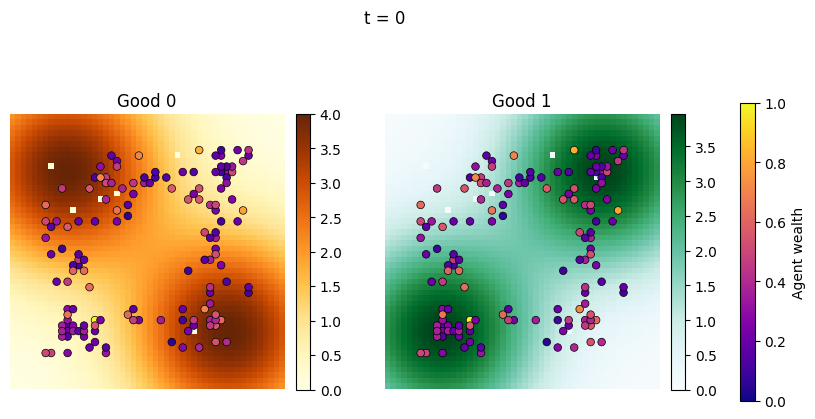

In [10]:
seed = 1


df, agents_history, env_history, trades_df, snapshots = run(
    time_steps=500,
    n_agents=150,
    env_size=(50, 50),
    resource_fns=make_anti_correlated_2good(50, 50),
    seed=seed,
    preferences_mean=[.1, .9],
    live=False,
    record=True
)

anim = animate(
    df,
    agents_history,
    env_history,
    save_path= f"output/model_run/run_seed{seed}.mp4" #f"output/model_run/run_seed{seed}.gif"   # or f"run_seed{seed}.mp4"
)

display(df)


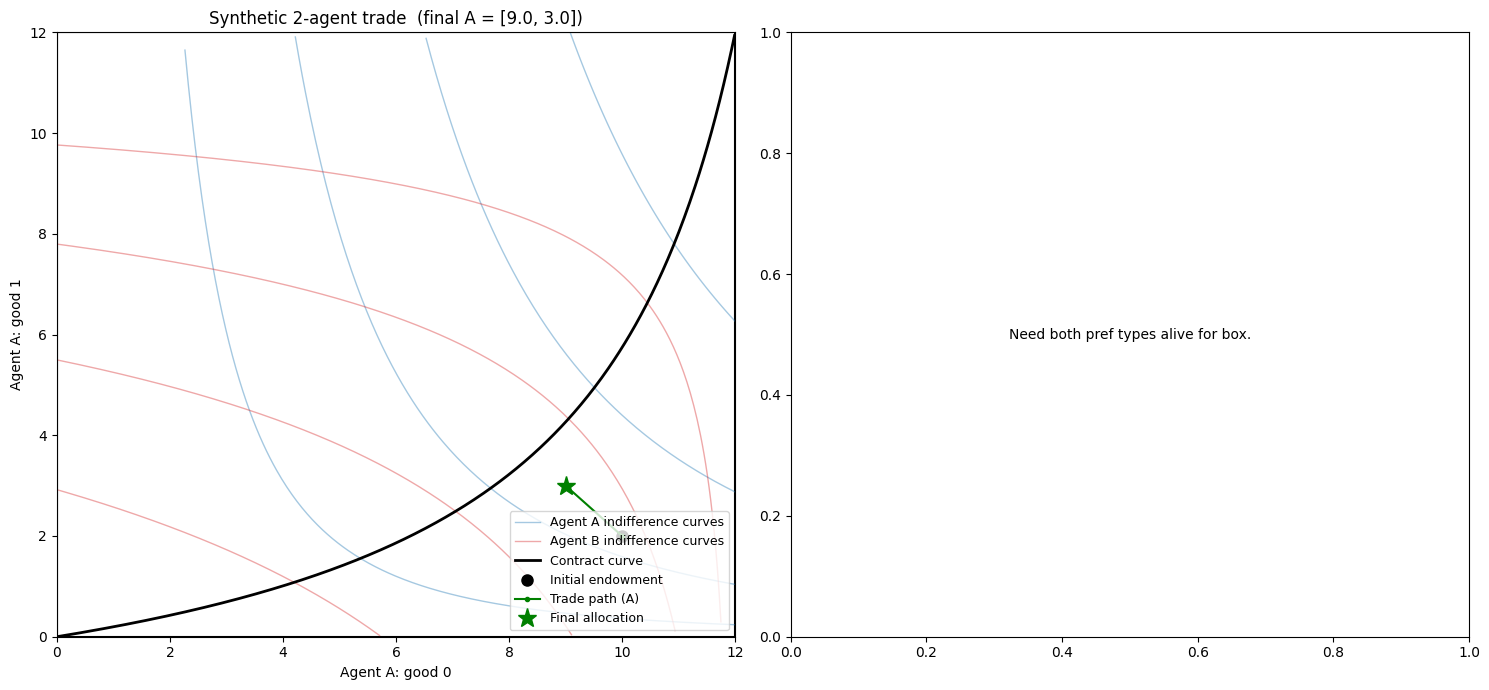


Market activity (first 10 steps):
   t  n_alive  n_trades  geo_mean_price  log_price_sd
0  0      143       162        0.313029      0.828231
1  1      142        27        0.197661      0.532644
2  2      142        15        0.222995      0.507975
3  3      140        10        0.225578      0.514947
4  4      139         2        0.385709      0.017336
5  5      139         4        0.286047      0.566418
6  6      138         5        0.434411      0.312615
7  7      135         3        0.540889      0.185667
8  8      135        10        0.437173      0.216964
9  9      133         3        0.565684      0.224657

Total trades over run: 19238
Total trade rows in trades_df (logged on each side): 38478


In [11]:
# ============================================================================
# Edgeworth Box: visualise bilateral trade between two agents.
#
# The Edgeworth box is the canonical 2-good, 2-agent diagram for evaluating
# whether an exchange economy reaches a Pareto-efficient allocation
# (Mas-Colell, Whinston & Green 1995, Microeconomic Theory, Ch. 15).
#
# How to read it:
#   * X-axis: agent A's holding of good 0. Width of box = total good 0.
#   * Y-axis: agent A's holding of good 1. Height of box = total good 1.
#   * Agent B's origin is the TOP-RIGHT corner; B's holdings are read by
#     subtracting from the box dimensions.
#   * Each point in the box is a feasible allocation of the two-agent economy.
#   * Indifference curves through any point show level sets of utility for
#     each agent.
#   * The locus where indifference curves are tangent is the CONTRACT CURVE:
#     every Pareto-efficient allocation given the total endowment.
#   * For Cobb-Douglas with weights (a0, a1) for A and (b0, b1) for B, the
#     contract curve has a closed form and is plotted exactly below.
#
# We draw two boxes:
#   1. A synthetic 2-agent example so you can see the mechanics on a clean case.
#   2. The aggregated economy from the simulation (using mean preferences) to
#      check whether the realised total holdings move toward the contract curve.
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt


def edgeworth_box(bundle_A, bundle_B, prefs_A, prefs_B,
                  trade_path=None, title="Edgeworth Box",
                  ax=None, n_curves=4):
    """Draw an Edgeworth box for two Cobb-Douglas agents.

    Parameters
    ----------
    bundle_A, bundle_B : array of shape (2,)
        Initial holdings of [good_0, good_1] for each agent.
    prefs_A, prefs_B : array of shape (2,)
        Cobb-Douglas weights; will be normalised internally.
    trade_path : list[tuple[float, float]] or None
        Optional sequence of A's bundles over a trade sequence; drawn as a path.
    title : str
        Plot title.
    ax : matplotlib axis or None
        If None, a new figure is created.
    n_curves : int
        Number of indifference curves per agent to draw.
    """
    W0 = bundle_A[0] + bundle_B[0]   # total good 0
    W1 = bundle_A[1] + bundle_B[1]   # total good 1
    if W0 <= 0 or W1 <= 0:
        raise ValueError("Total endowment of each good must be positive.")

    aA = np.asarray(prefs_A, dtype=float); aA = aA / aA.sum()
    aB = np.asarray(prefs_B, dtype=float); aB = aB / aB.sum()

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))

    # --- Box frame ---
    ax.add_patch(plt.Rectangle((0, 0), W0, W1, fill=False, lw=1.5))

    # --- Indifference curves for A (origin bottom-left) ---
    # U_A = q0^aA[0] * q1^aA[1].  Solve q1 = (U_A / q0^aA[0])^(1/aA[1])
    q0_grid = np.linspace(W0 * 0.001, W0, 400)
    UA_init = (bundle_A[0] ** aA[0]) * (bundle_A[1] ** aA[1])
    levels_A = UA_init * np.linspace(0.6, 1.6, n_curves)
    for k, U in enumerate(levels_A):
        q1 = (U / (q0_grid ** aA[0])) ** (1.0 / aA[1])
        mask = (q1 > 0) & (q1 < W1)
        ax.plot(q0_grid[mask], q1[mask], color="tab:blue", alpha=0.4, lw=1,
                label="Agent A indifference curves" if k == 0 else None)

    # --- Indifference curves for B (origin top-right; flip both axes) ---
    UB_init = (bundle_B[0] ** aB[0]) * (bundle_B[1] ** aB[1])
    levels_B = UB_init * np.linspace(0.6, 1.6, n_curves)
    for k, U in enumerate(levels_B):
        # B sees holdings (W0-q0, W1-q1); curve in B-coords is (xB, yB) with
        # xB^aB[0] * yB^aB[1] = U  ==>  yB = (U / xB^aB[0])^(1/aB[1])
        xB = np.linspace(W0 * 0.001, W0, 400)
        yB = (U / (xB ** aB[0])) ** (1.0 / aB[1])
        # convert back to A-frame: q0 = W0 - xB, q1 = W1 - yB
        q0 = W0 - xB
        q1 = W1 - yB
        mask = (q1 > 0) & (q1 < W1) & (q0 > 0) & (q0 < W0)
        ax.plot(q0[mask], q1[mask], color="tab:red", alpha=0.4, lw=1,
                label="Agent B indifference curves" if k == 0 else None)

    # --- Contract curve (analytical for Cobb-Douglas) ---
    # Tangency: MRS_A = MRS_B  =>  (aA[1]/aA[0]) * q0_A/q1_A = (aB[1]/aB[0]) * q0_B/q1_B
    # Substituting q0_B = W0-q0_A, q1_B = W1-q1_A and solving gives a closed form.
    # Standard result: the contract curve is
    #   q1_A = (W1 * (aA[1]/aA[0]) * q0_A) /
    #          (W0 * (aB[1]/aB[0]) - q0_A * ((aB[1]/aB[0]) - (aA[1]/aA[0])))
    # (See e.g. Varian 1992, Microeconomic Analysis, Ch. 17.)
    rA = aA[1] / aA[0]
    rB = aB[1] / aB[0]
    q0_A = np.linspace(W0 * 0.001, W0 * 0.999, 500)
    denom = W0 * rB - q0_A * (rB - rA)
    q1_A = (W1 * rA * q0_A) / denom
    mask = (q1_A > 0) & (q1_A < W1)
    ax.plot(q0_A[mask], q1_A[mask], color="black", lw=2, label="Contract curve")

    # --- Initial endowment + trade path ---
    ax.plot(bundle_A[0], bundle_A[1], "ko", ms=8, label="Initial endowment")
    if trade_path is not None and len(trade_path) > 0:
        path = np.asarray(trade_path)
        ax.plot(path[:, 0], path[:, 1], "g.-", lw=1.5, ms=6, label="Trade path (A)")
        ax.plot(path[-1, 0], path[-1, 1], "g*", ms=14, label="Final allocation")

    ax.set_xlim(0, W0)
    ax.set_ylim(0, W1)
    ax.set_xlabel("Agent A: good 0")
    ax.set_ylabel("Agent A: good 1")
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=9)
    ax.set_aspect("auto")
    return ax


def trace_two_agent_trade(bundle_A, bundle_B, prefs_A, prefs_B,
                          good_i=0, good_j=1, max_iter=200):
    """Run two synthetic agents through ``Agent.trade`` and return the
    full sequence of A-side bundles for plotting in the Edgeworth box.

    This isolates the trade mechanism from movement, metabolism, and the
    grid — exactly the unit test you want before trusting market-level results.
    """
    # Build minimal Agent objects (vision/position/metab don't matter here).
    A = Agent(0, prefs_A, np.array(bundle_A, dtype=float), 1, (0, 0), np.ones(2))
    B = Agent(1, prefs_B, np.array(bundle_B, dtype=float), 1, (0, 1), np.ones(2))

    path = [A.bundle.copy()]
    # Step the trade loop one round at a time so we can record A's bundle after
    # each successful exchange. The Agent.trade method runs to convergence
    # internally; we instead drive a single pass and re-call until quiescent.
    for _ in range(max_iter):
        before = A.bundle.copy()
        # Single bilateral encounter; trade() iterates internally to MRS-equality.
        A.trade(B, good_i, good_j)
        path.append(A.bundle.copy())
        if np.allclose(A.bundle, before):
            break
    return np.array(path)


# ----- Demo 1: synthetic 2-agent box (clean test of trade mechanism) -----
prefs_A = np.array([0.7, 0.3])
prefs_B = np.array([0.3, 0.7])
bA = np.array([10.0, 2.0])
bB = np.array([2.0, 10.0])
path = trace_two_agent_trade(bA, bB, prefs_A, prefs_B)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
edgeworth_box(bA, bB, prefs_A, prefs_B, trade_path=path,
              title=f"Synthetic 2-agent trade  (final A = {path[-1].round(2).tolist()})",
              ax=axes[0])

# ----- Demo 2: real simulation aggregated to a representative pair -----
# Edgeworth box requires CONSTANT total endowment. Sugarscape agents harvest
# from the environment between trades, so totals change over time and a single
# fixed box cannot contain both initial and final allocations. We therefore
# show only the FINAL snapshot: build the box from the final group totals so
# the realised allocation is guaranteed to land inside the box, and read off
# its position relative to the contract curve (Pareto efficiency check).
init_prefs = snapshots["initial_preferences"]
final_bundles = snapshots["final_bundles"]
g0_pref = init_prefs[:, 0] / init_prefs.sum(axis=1) > 0.5
final_id_set = set(snapshots["final_ids"].tolist())
init_id_arr = snapshots["initial_ids"]
final_bundle_by_id = {int(i): b for i, b in zip(snapshots["final_ids"], final_bundles)}
g0_alive = [final_bundle_by_id[int(i)] for i, g in zip(init_id_arr, g0_pref)
            if g and int(i) in final_id_set]
g1_alive = [final_bundle_by_id[int(i)] for i, g in zip(init_id_arr, g0_pref)
            if (not g) and int(i) in final_id_set]
if g0_alive and g1_alive:
    bA_final = np.mean(g0_alive, axis=0)
    bB_final = np.mean(g1_alive, axis=0)
    pA_mean  = init_prefs[g0_pref].mean(axis=0)
    pB_mean  = init_prefs[~g0_pref].mean(axis=0)
    # Pass bA_final as both "endowment" and "final" so the box sizes correctly
    # and the green star + black dot coincide at the realised allocation.
    edgeworth_box(bA_final, bB_final, pA_mean, pB_mean,
                  trade_path=np.array([bA_final]),
                  title="Simulated economy: terminal allocation (snapshot)",
                  ax=axes[1])
else:
    axes[1].text(0.5, 0.5, "Need both pref types alive for box.",
                 ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.show()


# ----- Sanity: print per-step trade activity -----
print("\nMarket activity (first 10 steps):")
print(df[["t", "n_alive", "n_trades", "geo_mean_price", "log_price_sd"]].head(10))
print(f"\nTotal trades over run: {df['n_trades'].sum()}")
print(f"Total trade rows in trades_df (logged on each side): {len(trades_df)}")


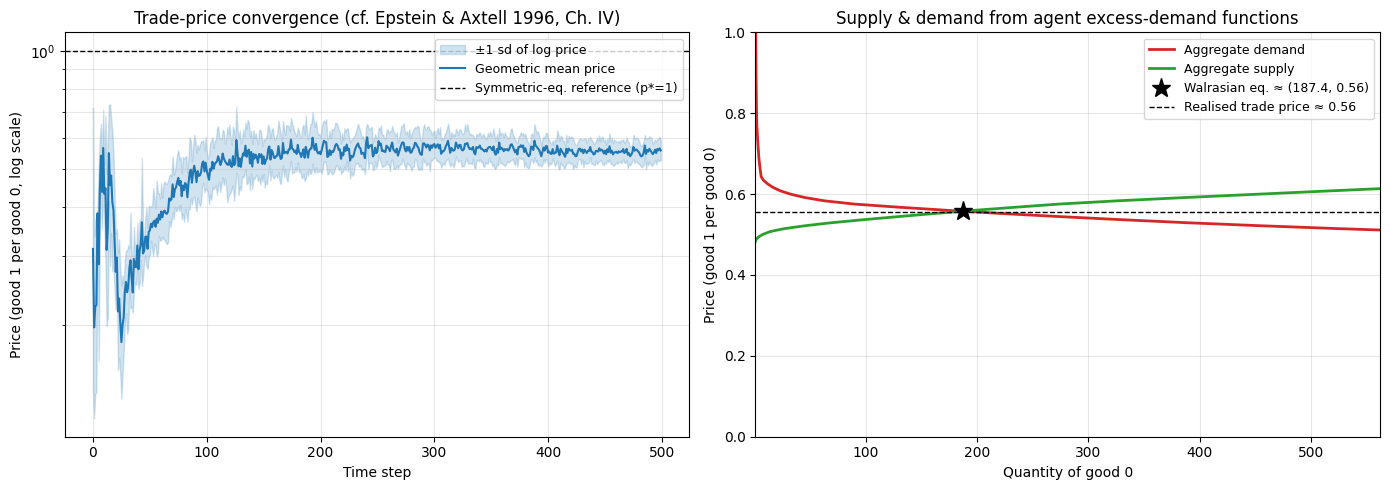

In [12]:
# ============================================================================
# Supply & Demand Visualisation (per Epstein & Axtell 1996, Ch. IV)
#
# Two panels:
#  (A) Trade-price time series with cross-sectional dispersion band — the
#      canonical Sugarscape price-convergence plot (Epstein & Axtell 1996,
#      "Growing Artificial Societies", Ch. IV — book index lists "Average
#      Trade Price", "Logarithm of Average ... Price", "Standard Deviation"
#      as the price-statistic plots they use; see also the Mesa replication
#      which logs `geometric_mean(prices)` per step:
#      mesa.readthedocs.io/stable/examples/advanced/sugarscape_g1mt.html).
#
#  (B) Marshallian supply/demand cross built from agents end-of-run MRS
#      distributions. Each agent has a private reservation price for one
#      additional unit of good 0 (their MRS_{0,1}). Agents with low MRS
#      are willing to SELL good 0 cheaply; agents with high MRS are willing
#      to BUY good 0 expensively. Sorting sellers ascending by MRS and
#      buyers descending gives Marshallian supply and demand curves; the
#      crossing identifies the market-clearing price and quantity.
#      This MRS-based supply/demand construction is the standard ABM way
#      to visualise pre-trade demand and supply schedules in a Walrasian
#      sense (Tesfatsion & Judd, eds., 2006, "Handbook of Computational
#      Economics, Vol. 2: Agent-Based Computational Economics", Ch. 16).
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel A: price time series with dispersion band ---
ax = axes[0]
t   = df["t"].to_numpy()
p   = df["geo_mean_price"].to_numpy()      # geometric mean of trades / step
sd  = df["log_price_sd"].to_numpy()         # cross-sectional std of log price
mask = ~np.isnan(p)
ax.fill_between(t[mask], np.exp(np.log(p[mask]) - sd[mask]),
                         np.exp(np.log(p[mask]) + sd[mask]),
                color="tab:blue", alpha=0.20, label="±1 sd of log price")
ax.plot(t[mask], p[mask], color="tab:blue", lw=1.5, label="Geometric mean price")
ax.axhline(1.0, color="black", ls="--", lw=1, label="Symmetric-eq. reference (p*=1)")
ax.set_yscale("log")
ax.set_xlabel("Time step")
ax.set_ylabel("Price (good 1 per good 0, log scale)")
ax.set_title("Trade-price convergence (cf. Epstein & Axtell 1996, Ch. IV)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, which="both", alpha=0.3)

# --- Panel B: aggregate supply & demand curves with a true crossing ---
# At each candidate price p, every agent computes their Cobb-Douglas optimal
# bundle (q0*, q1*) given wealth W = p*q0 + q1. The agent's excess demand for
# good 0 is q0* - q0_current: positive means they would buy that quantity,
# negative means they would sell. Aggregating across agents at each p gives
# downward-sloping aggregate demand and upward-sloping aggregate supply
# curves; their intersection is the Walrasian market-clearing price.
# (Mas-Colell, Whinston & Green 1995, Microeconomic Theory, Ch. 15.B,
#  "Aggregate Excess Demand"; Varian 1992, Microeconomic Analysis, Ch. 17.)
ax = axes[1]
final_bundles = snapshots["final_bundles"]
final_ids     = snapshots["final_ids"]
pref_by_id    = {int(i): p for i, p in zip(snapshots["initial_ids"],
                                            snapshots["initial_preferences"])}
prefs_norm = np.array([pref_by_id[int(i)] / pref_by_id[int(i)].sum()
                       for i in final_ids])
bundles = np.asarray(final_bundles, dtype=float)
keep = (bundles[:, 0] > 0) & (bundles[:, 1] > 0)
bundles, prefs_norm = bundles[keep], prefs_norm[keep]

# Sweep prices around the realised price to draw both curves.
ref_p = np.exp(np.nanmean(np.log(df["geo_mean_price"].tail(10))))
p_grid = np.geomspace(ref_p / 4, ref_p * 4, 200)
agg_demand, agg_supply = np.zeros_like(p_grid), np.zeros_like(p_grid)
for k, p in enumerate(p_grid):
    W = p * bundles[:, 0] + bundles[:, 1]            # wealth in units of good 1
    q0_star = prefs_norm[:, 0] * W / p               # Cobb-Douglas optimum
    excess = q0_star - bundles[:, 0]                 # +buy / -sell
    agg_demand[k] = excess[excess > 0].sum()
    agg_supply[k] = -excess[excess < 0].sum()

ax.plot(agg_demand, p_grid, color="tab:red",   lw=2, label="Aggregate demand")
ax.plot(agg_supply, p_grid, color="tab:green", lw=2, label="Aggregate supply")

# Numerical equilibrium: where supply == demand (sign change of supply - demand).
diff = agg_supply - agg_demand
sign_change = np.where(np.diff(np.sign(diff)))[0]
if len(sign_change):
    j = sign_change[0]
    p_star = float(np.interp(0, [diff[j], diff[j+1]], [p_grid[j], p_grid[j+1]]))
    q_star = float(np.interp(p_star, p_grid, agg_demand))
    ax.plot(q_star, p_star, "k*", ms=14, label=f"Walrasian eq. ≈ ({q_star:.1f}, {p_star:.2f})")
ax.axhline(ref_p, color="black", ls="--", lw=1,
           label=f"Realised trade price ≈ {ref_p:.2f}")
# Clip x-axis around the crossing for legibility — Cobb-Douglas demand
# diverges as p->0, so without clipping the crossing collapses to the y-axis.
xmax = 3 * (q_star if len(sign_change) else max(agg_demand.max(), agg_supply.max()))
ax.set_xlim(1, xmax)
ax.set_ylim(0, 1)
ax.set_xlabel("Quantity of good 0")
ax.set_ylabel("Price (good 1 per good 0)")
ax.set_title("Supply & demand from agent excess-demand functions")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
